In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the feather file
df = pd.read_feather('lending_club_clean.feather') 

# Quick check
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()[:10]}...")  # First 10 columns
print(f"\nFirst few rows of int_rate:")
print(df['int_rate'].head(10))

Shape: (2925492, 141)

Columns: ['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title']...

First few rows of int_rate:
0    0.1065
1    0.1527
2    0.1596
3    0.1349
4    0.1269
5    0.0790
6    0.1596
7    0.1864
8    0.2128
9    0.1269
Name: int_rate, dtype: float32


In [2]:

# ============================================================
# 1. DATASET OVERVIEW
# ============================================================
print("=" * 60)
print("1. DATASET SHAPE")
print("=" * 60)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# ============================================================
# 2. Variable type breakdown
# ============================================================
print("\n" + "=" * 60)
print("2. VARIABLE TYPE BREAKDOWN")
print("=" * 60)
dtype_counts = df.dtypes.astype(str).value_counts()
print(dtype_counts)

# ============================================================
# 3. int_rate descriptive statistics
# ============================================================
print("\n" + "=" * 60)
print("3. int_rate DESCRIPTIVE STATISTICS")
print("=" * 60)
int_rate_pct = df['int_rate'] * 100  # convert to percentage
print(int_rate_pct.describe())
print(f"\nInterest rate ranges from {int_rate_pct.min():.2f}% to {int_rate_pct.max():.2f}%")

# ============================================================
# 4. All column names grouped by dtype (using string repr)
# ============================================================
print("\n" + "=" * 60)
print("4. ALL COLUMN NAMES GROUPED BY DTYPE")
print("=" * 60)
dtype_strings = df.dtypes.astype(str)
for dtype_name in sorted(dtype_strings.unique()):
    cols = dtype_strings[dtype_strings == dtype_name].index.tolist()
    print(f"\n--- {dtype_name} ({len(cols)} columns) ---")
    for col in cols:
        print(f"  {col}")

# ============================================================
# 5. Key column statistics
# ============================================================
cols_to_inspect = [
    'fico_range_low', 'fico_range_high', 'annual_inc', 'dti',
    'loan_amnt', 'term', 'purpose', 'emp_length', 'home_ownership',
    'delinq_2yrs', 'revol_util', 'open_acc', 'pub_rec', 'revol_bal',
    'mort_acc', 'pub_rec_bankruptcies', 'verification_status',
    'addr_state', 'application_type'
]

print("\n" + "=" * 60)
print("5. DESCRIBE & VALUE_COUNTS FOR KEY COLUMNS")
print("=" * 60)
for col in cols_to_inspect:
    if col not in df.columns:
        print(f"\n  *** {col} NOT FOUND ***")
        continue
    print(f"\n{'─' * 50}")
    print(f"  Column: {col}  |  dtype: {df[col].dtype}  |  nulls: {df[col].isnull().sum():,}")
    print(f"{'─' * 50}")
    try:
        print(df[col].describe())
    except Exception:
        print(f"  unique: {df[col].nunique()}, top: {df[col].mode().iloc[0] if len(df[col].mode()) > 0 else 'N/A'}")
    print(f"\nValue counts (top 10):")
    print(df[col].value_counts().head(10))

# ============================================================
# 6. Missing values — top 30
# ============================================================
print("\n" + "=" * 60)
print("6. MISSING VALUES (top 30 columns)")
print("=" * 60)
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(30))
print(f"\nTotal columns with any missing: {(missing > 0).sum()}")

# ============================================================
# 7. annual_inc percentiles
# ============================================================
print("\n" + "=" * 60)
print("7. annual_inc PERCENTILES")
print("=" * 60)
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]
print(df['annual_inc'].quantile(percentiles))


1. DATASET SHAPE
Rows: 2,925,492
Columns: 141

2. VARIABLE TYPE BREAKDOWN
Int16             54
float32           26
category          22
Int64             15
Int32             15
datetime64[ns]     9
Name: count, dtype: int64

3. int_rate DESCRIPTIVE STATISTICS
count    2.925492e+06
mean     1.304545e+01
std      4.868254e+00
min      5.310000e+00
25%      9.170000e+00
50%      1.249000e+01
75%      1.599000e+01
max      3.099000e+01
Name: int_rate, dtype: float64

Interest rate ranges from 5.31% to 30.99%

4. ALL COLUMN NAMES GROUPED BY DTYPE

--- Int16 (54 columns) ---
  term
  delinq_2yrs
  inq_last_6mths
  mths_since_last_delinq
  mths_since_last_record
  open_acc
  pub_rec
  total_acc
  collections_12_mths_ex_med
  mths_since_last_major_derog
  policy_code
  acc_now_delinq
  open_acc_6m
  open_act_il
  open_il_12m
  open_il_24m
  open_rv_12m
  open_rv_24m
  all_util
  inq_fi
  total_cu_tl
  inq_last_12m
  acc_open_past_24mths
  chargeoff_within_12_mths
  mort_acc
  mths_since_rece

## Recommended Predictor Variables (15-20)

**Excluded (data leakage):** grade, sub_grade, installment, total_pymnt*, last_pymnt*, recoveries, hardship_*, collection_recovery_fee, funded_amnt, funded_amnt_inv

**Selected predictors** — features known at loan origination:

In [3]:

# ============================================================
# RECOMMENDED PREDICTOR VARIABLES (known at origination)
# ============================================================

recommended_predictors = {
    # --- Borrower Credit Profile ---
    'fico_range_low':       'FICO credit score (lower bound)',
    'fico_range_high':      'FICO credit score (upper bound)',
    'dti':                  'Debt-to-income ratio',
    'delinq_2yrs':          'Delinquencies in past 2 years',
    'inq_last_6mths':       'Credit inquiries in last 6 months',
    'open_acc':             'Number of open credit lines',
    'pub_rec':              'Number of derogatory public records',
    'revol_bal':            'Total revolving balance ($)',
    'revol_util':           'Revolving utilization rate (%)',
    'pub_rec_bankruptcies': 'Number of public record bankruptcies',
    'mort_acc':             'Number of mortgage accounts',
    'earliest_cr_line':     'Date of earliest credit line (proxy for credit age)',
    
    # --- Loan Characteristics ---
    'loan_amnt':            'Loan amount requested ($)',
    'term':                 'Loan term (36 or 60 months)',
    'purpose':              'Purpose of the loan',
    
    # --- Borrower Demographics/Financial ---
    'annual_inc':           'Annual income ($)',
    'emp_length':           'Employment length (years)',
    'home_ownership':       'Home ownership status',
    'verification_status':  'Income verification status',
    'application_type':     'Individual vs Joint application',
    'addr_state':           'Borrower state (geographic risk)',
}

print(f"Total recommended predictors: {len(recommended_predictors)}\n")
print(f"{'Variable':<25} {'Description':<50} {'In Dataset?'}")
print("─" * 85)
for var, desc in recommended_predictors.items():
    exists = "YES" if var in df.columns else "NO"
    print(f"{var:<25} {desc:<50} {exists}")

# Check which are available
available = [v for v in recommended_predictors if v in df.columns]
print(f"\nAvailable in dataset: {len(available)} / {len(recommended_predictors)}")


Total recommended predictors: 21

Variable                  Description                                        In Dataset?
─────────────────────────────────────────────────────────────────────────────────────
fico_range_low            FICO credit score (lower bound)                    YES
fico_range_high           FICO credit score (upper bound)                    YES
dti                       Debt-to-income ratio                               YES
delinq_2yrs               Delinquencies in past 2 years                      YES
inq_last_6mths            Credit inquiries in last 6 months                  YES
open_acc                  Number of open credit lines                        YES
pub_rec                   Number of derogatory public records                YES
revol_bal                 Total revolving balance ($)                        YES
revol_util                Revolving utilization rate (%)                     YES
pub_rec_bankruptcies      Number of public record bankruptcies

---
## Visualizations: Predictors vs. Interest Rate

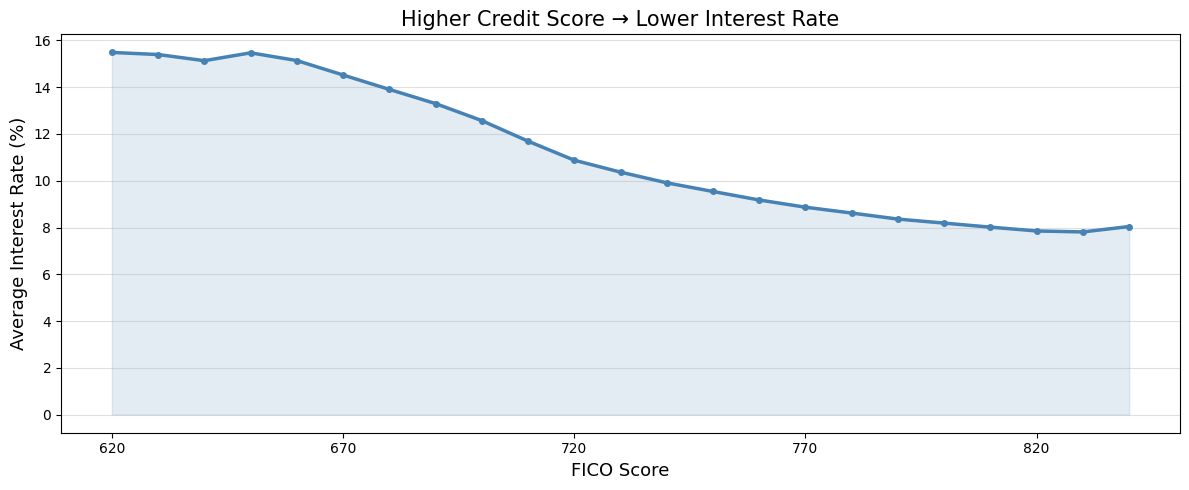

In [7]:

# ============================================================
# VIZ 1: FICO Score vs Interest Rate
# Bin FICO into groups, show average rate per group
# ============================================================
plot_df = df[['fico_range_low', 'int_rate']].dropna().copy()
plot_df['int_rate_pct'] = plot_df['int_rate'] * 100

# Bin into 10-point FICO buckets, label them cleanly
plot_df['fico_bucket'] = pd.cut(plot_df['fico_range_low'],
                                bins=range(620, 860, 10),
                                labels=[str(x) for x in range(620, 850, 10)])

summary = plot_df.groupby('fico_bucket', observed=True)['int_rate_pct'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(summary.index.astype(str), summary.values, color='steelblue', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(range(len(summary)), summary.values, alpha=0.15, color='steelblue')

# Only label every 5th tick so x-axis isn't crowded
ticks = list(range(0, len(summary), 5))
ax.set_xticks(ticks)
ax.set_xticklabels([summary.index[i] for i in ticks], rotation=0)

ax.set_xlabel('FICO Score', fontsize=13)
ax.set_ylabel('Average Interest Rate (%)', fontsize=13)
ax.set_title('Higher Credit Score → Lower Interest Rate', fontsize=15)
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('viz1_fico_vs_rate.png', dpi=150, bbox_inches='tight')
plt.show()


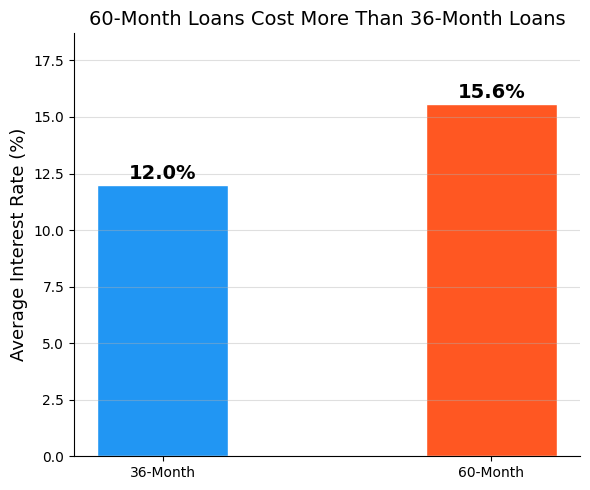

  36-month loans: 2,060,077 (70.4%)
  60-month loans: 865,415 (29.6%)


In [8]:

# ============================================================
# VIZ 2: Average Interest Rate by Loan Term
# Two bars, that's it
# ============================================================
plot_df = df[['term', 'int_rate']].dropna().copy()
plot_df['int_rate_pct'] = plot_df['int_rate'] * 100
plot_df['term_clean'] = plot_df['term'].astype(str).str.extract(r'(\d+)').astype(float)

summary = plot_df.groupby('term_clean')['int_rate_pct'].mean().reset_index()
summary['label'] = summary['term_clean'].apply(lambda x: f'{x:.0f}-Month')

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(summary['label'], summary['int_rate_pct'],
              color=['#2196F3', '#FF5722'], width=0.4, edgecolor='white')

for bar, val in zip(bars, summary['int_rate_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Average Interest Rate (%)', fontsize=13)
ax.set_title('60-Month Loans Cost More Than 36-Month Loans', fontsize=14)
ax.set_ylim(0, summary['int_rate_pct'].max() * 1.2)
ax.grid(True, axis='y', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz2_term_vs_rate.png', dpi=150, bbox_inches='tight')
plt.show()

counts = plot_df.groupby('term_clean').size()
for t, n in counts.items():
    print(f"  {t:.0f}-month loans: {n:,} ({n/len(plot_df)*100:.1f}%)")


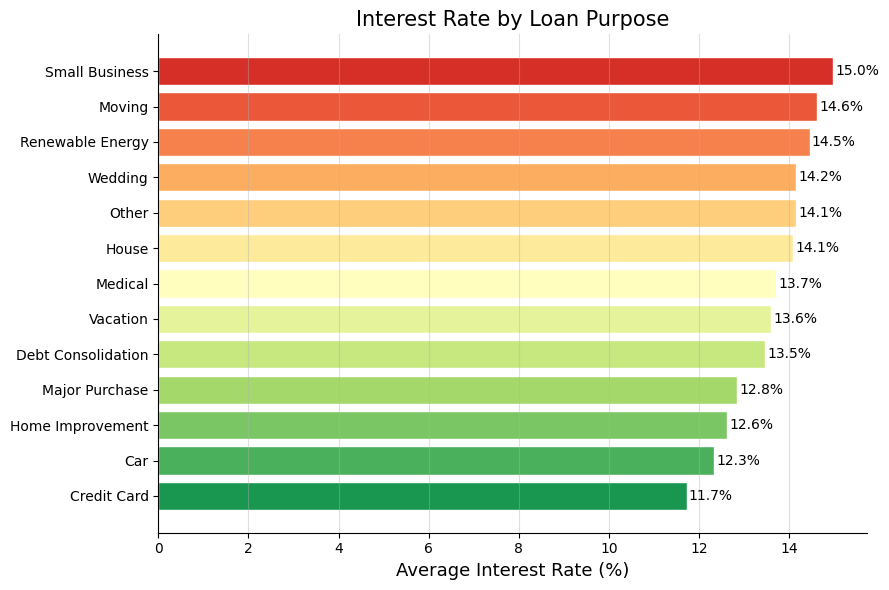

In [9]:

# ============================================================
# VIZ 3: Average Interest Rate by Loan Purpose
# Horizontal bar chart, sorted lowest to highest
# ============================================================
plot_df = df[['purpose', 'int_rate']].dropna().copy()
plot_df['int_rate_pct'] = plot_df['int_rate'] * 100

summary = (plot_df.groupby('purpose', observed=True)['int_rate_pct']
           .agg(mean='mean', count='count')
           .query('count >= 1000')
           .sort_values('mean'))

# Clean up category names for display
summary.index = (summary.index.astype(str)
                 .str.replace('_', ' ')
                 .str.title())

fig, ax = plt.subplots(figsize=(9, 6))

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(summary)))
bars = ax.barh(summary.index, summary['mean'], color=colors, edgecolor='white')

for bar, val in zip(bars, summary['mean']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Average Interest Rate (%)', fontsize=13)
ax.set_title('Interest Rate by Loan Purpose', fontsize=15)
ax.grid(True, axis='x', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz3_purpose_vs_rate.png', dpi=150, bbox_inches='tight')
plt.show()
